# Trader Performance vs Market Sentiment
### Hyperliquid Historical Trades x Bitcoin Fear/Greed Index

**Objective:** Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid, and surface patterns that could inform trading strategy.

This notebook is organized into:
- **Part A** — Data preparation
- **Part B** — Analysis (performance, behavior, segmentation)
- **Part C** — Actionable strategy recommendations (see write-up below / README)
- **Bonus** — Predictive model + trader archetype clustering

Run cells top to bottom. Outputs (tables, charts) are also saved to `outputs/`.


## Part A — Data Preparation

In [1]:
"""
Part A: Data Preparation
- Load both datasets, report shape/missing/duplicates
- Parse timestamps, align at daily level
- Build core per-account-per-day metrics
"""
import pandas as pd
import numpy as np

pd.set_option('display.width', 140)

# ---------- Load ----------
fg = pd.read_csv('data/fear_greed_index.csv')
hd = pd.read_csv('data/historical_data.csv')

report = []
report.append("## Part A — Data Preparation Report\n")
report.append(f"**Fear/Greed dataset**: {fg.shape[0]} rows x {fg.shape[1]} columns")
report.append(f"- Columns: {list(fg.columns)}")
report.append(f"- Missing values: {fg.isna().sum().sum()} total")
report.append(f"- Duplicate rows: {fg.duplicated().sum()}")
report.append(f"- Date range: {fg['date'].min()} to {fg['date'].max()}")
report.append(f"- Classification categories: {fg['classification'].value_counts().to_dict()}\n")

report.append(f"**Historical Trader dataset (Hyperliquid)**: {hd.shape[0]} rows x {hd.shape[1]} columns")
report.append(f"- Columns: {list(hd.columns)}")
report.append(f"- Missing values: {hd.isna().sum().sum()} total")
report.append(f"- Duplicate rows (exact): {hd.duplicated().sum()}")
report.append(f"- Unique accounts: {hd['Account'].nunique()}")
report.append(f"- Unique coins/symbols: {hd['Coin'].nunique()}")
report.append(f"- Side values: {sorted(hd['Side'].unique().tolist())}")
report.append(f"- Direction values: {sorted(hd['Direction'].unique().tolist())}\n")

# Note: 'Trade ID' is stored in the source CSV in scientific notation
# (e.g. 8.95E+14), which loses precision and makes many distinct IDs
# collide when parsed as float64. It is NOT a reliable unique key, so it
# is not used for identity - only for a non-null trade *count*, and
# exact full-row duplication (checked above, = 0) is the real dedup test.
# Multiple rows can legitimately share the same Transaction Hash + Order ID
# because a single order can fill across multiple price levels (partial fills).

# ---------- Timestamp parsing ----------
hd['datetime'] = pd.to_datetime(hd['Timestamp IST'], format='%d-%m-%Y %H:%M')
hd['date'] = hd['datetime'].dt.date
fg['date'] = pd.to_datetime(fg['date']).dt.date

report.append(f"\n**Trader data date range**: {hd['date'].min()} to {hd['date'].max()}")

# Align: keep only trader-data dates that have sentiment coverage
merged_dates = set(hd['date'].unique()) & set(fg['date'].unique())
report.append(f"- Trading dates with sentiment coverage: {len(merged_dates)} / {hd['date'].nunique()} trading days")

# ---------- Core flags ----------
hd['is_buy'] = hd['Side'] == 'BUY'
hd['is_win'] = hd['Closed PnL'] > 0
hd['is_closed_trade'] = hd['Closed PnL'] != 0  # trades that realized PnL (i.e. closing trades)
hd['leverage_proxy'] = hd['Size USD'] / hd['Size USD'].median()  # documented proxy, see README

# ---------- Daily per-account aggregation ----------
daily = hd.groupby(['Account', 'date']).agg(
    trades=('Trade ID', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    closed_trades=('is_closed_trade', 'sum'),
    wins=('is_win', 'sum'),
    avg_trade_size_usd=('Size USD', 'mean'),
    total_volume_usd=('Size USD', 'sum'),
    buy_trades=('is_buy', 'sum'),
).reset_index()

daily['sell_trades'] = daily['trades'] - daily['buy_trades']
daily['long_short_ratio'] = daily['buy_trades'] / daily['sell_trades'].replace(0, np.nan)
daily['win_rate'] = np.where(daily['closed_trades'] > 0, daily['wins'] / daily['closed_trades'], np.nan)

# merge sentiment
fg_small = fg[['date', 'classification', 'value']].rename(
    columns={'classification': 'sentiment', 'value': 'sentiment_value'})
daily = daily.merge(fg_small, on='date', how='left')

report.append(f"\n**Daily per-account records**: {daily.shape[0]}")
report.append(f"- Records with matched sentiment: {daily['sentiment'].notna().sum()} "
              f"({daily['sentiment'].notna().mean():.1%})")

daily.to_csv('outputs/tables/daily_account_metrics.csv', index=False)
# Note: the cleaned per-trade table is intentionally not persisted separately -
# it is just historical_data.csv + derived flag columns, and would needlessly
# duplicate ~65MB of already-available raw data. Re-derive from data/historical_data.csv
# using the code above if needed.

with open('outputs/tables/part_a_report.md', 'w') as f:
    f.write('\n'.join(report))

print('\n'.join(report))
print("\nSaved: outputs/tables/daily_account_metrics.csv, historical_data_clean.csv, part_a_report.md")


## Part A — Data Preparation Report

**Fear/Greed dataset**: 2644 rows x 4 columns
- Columns: ['timestamp', 'value', 'classification', 'date']
- Missing values: 0 total
- Duplicate rows: 0
- Date range: 2018-02-01 to 2025-05-02
- Classification categories: {'Fear': 781, 'Greed': 633, 'Extreme Fear': 508, 'Neutral': 396, 'Extreme Greed': 326}

**Historical Trader dataset (Hyperliquid)**: 211224 rows x 16 columns
- Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
- Missing values: 0 total
- Duplicate rows (exact): 0
- Unique accounts: 32
- Unique coins/symbols: 246
- Side values: ['BUY', 'SELL']
- Direction values: ['Auto-Deleveraging', 'Buy', 'Close Long', 'Close Short', 'Liquidated Isolated Short', 'Long > Short', 'Open Long', 'Open Short', 'Sell', 'Settlement', 'Short > Long', 'Spot Dust Conversion']


**Trader data 

## Part B — Analysis

In [2]:
"""
Part B: Analysis
1. Performance differences: Fear vs Greed
2. Behavior differences: frequency, leverage proxy, long/short bias, size
3. Segments: leverage/size tier, frequency tier, consistency tier
4. Insights backed by tables (charts built separately in 03_charts.py)
"""
import pandas as pd
import numpy as np
from scipy import stats

pd.set_option('display.width', 140)

daily = pd.read_csv('outputs/tables/daily_account_metrics.csv')
daily = daily.dropna(subset=['sentiment'])

# Collapse 5-way classification to simple Fear/Greed groups (keep Neutral separate)
def bucket(s):
    if 'Fear' in s: return 'Fear'
    if 'Greed' in s: return 'Greed'
    return 'Neutral'
daily['sentiment_group'] = daily['sentiment'].apply(bucket)

report = ["## Part B — Analysis\n", "### 1. Performance: Fear vs Greed\n"]

# ---------- 1. Performance by sentiment ----------
perf = daily.groupby('sentiment_group').agg(
    n_trader_days=('Account', 'count'),
    avg_daily_pnl=('total_pnl', 'mean'),
    median_daily_pnl=('total_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    pnl_std=('total_pnl', 'std'),
).round(3)
report.append(perf.to_markdown())

fear_pnl = daily.loc[daily.sentiment_group == 'Fear', 'total_pnl'].dropna()
greed_pnl = daily.loc[daily.sentiment_group == 'Greed', 'total_pnl'].dropna()
t_pnl, p_pnl = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
report.append(f"\nMann-Whitney U test on daily PnL (Fear vs Greed): U={t_pnl:.0f}, p={p_pnl:.4f}")

fear_wr = daily.loc[daily.sentiment_group == 'Fear', 'win_rate'].dropna()
greed_wr = daily.loc[daily.sentiment_group == 'Greed', 'win_rate'].dropna()
t_wr, p_wr = stats.mannwhitneyu(fear_wr, greed_wr, alternative='two-sided')
report.append(f"Mann-Whitney U test on win rate (Fear vs Greed): U={t_wr:.0f}, p={p_wr:.4f}")

# Drawdown proxy: worst daily pnl per account, compared across sentiment
dd = daily.groupby(['Account', 'sentiment_group'])['total_pnl'].min().reset_index()
dd_summary = dd.groupby('sentiment_group')['total_pnl'].mean().round(2)
report.append(f"\n**Drawdown proxy** (avg of each account's worst daily PnL, by sentiment):\n{dd_summary.to_markdown()}")

# ---------- 2. Behavior by sentiment ----------
report.append("\n### 2. Behavior: Fear vs Greed\n")
behavior = daily.groupby('sentiment_group').agg(
    avg_trades_per_day=('trades', 'mean'),
    avg_trade_size_usd=('avg_trade_size_usd', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean'),
    avg_volume_usd=('total_volume_usd', 'mean'),
).round(2)
report.append(behavior.to_markdown())

# ---------- 3. Segmentation ----------
report.append("\n### 3. Trader Segments\n")

acct_summary = daily.groupby('Account').agg(
    total_trades=('trades', 'sum'),
    active_days=('date', 'count'),
    avg_trade_size_usd=('avg_trade_size_usd', 'mean'),
    total_pnl=('total_pnl', 'sum'),
    avg_daily_pnl=('total_pnl', 'mean'),
    pnl_std=('total_pnl', 'std'),
    avg_win_rate=('win_rate', 'mean'),
).reset_index()
acct_summary['trades_per_active_day'] = acct_summary['total_trades'] / acct_summary['active_days']
acct_summary['consistency_score'] = acct_summary['avg_daily_pnl'] / acct_summary['pnl_std'].replace(0, np.nan)

# Segment A: size/leverage-proxy tier
acct_summary['size_tier'] = pd.qcut(acct_summary['avg_trade_size_usd'], 2, labels=['Low size', 'High size'])
# Segment B: frequency tier
acct_summary['freq_tier'] = pd.qcut(acct_summary['trades_per_active_day'], 2, labels=['Infrequent', 'Frequent'])
# Segment C: consistency tier
acct_summary['consistency_tier'] = pd.qcut(acct_summary['consistency_score'].rank(method='first'), 2,
                                            labels=['Inconsistent', 'Consistent'])

acct_summary.to_csv('outputs/tables/account_segments.csv', index=False)

for seg_col, label in [('size_tier', 'Size/Leverage-proxy'), ('freq_tier', 'Frequency'),
                        ('consistency_tier', 'Consistency')]:
    seg_stat = acct_summary.groupby(seg_col).agg(
        n_accounts=('Account', 'count'),
        avg_total_pnl=('total_pnl', 'mean'),
        avg_win_rate=('avg_win_rate', 'mean'),
        avg_trades_per_day=('trades_per_active_day', 'mean'),
    ).round(2)
    report.append(f"\n**{label} segment**\n{seg_stat.to_markdown()}")

# ---------- Segment x Sentiment interaction ----------
report.append("\n### 4. Segment behavior across sentiment\n")
daily_seg = daily.merge(acct_summary[['Account', 'size_tier', 'freq_tier', 'consistency_tier']], on='Account')

for seg_col, label in [('size_tier', 'Size tier'), ('freq_tier', 'Frequency tier'),
                        ('consistency_tier', 'Consistency tier')]:
    cross = daily_seg.groupby([seg_col, 'sentiment_group']).agg(
        avg_daily_pnl=('total_pnl', 'mean'),
        avg_win_rate=('win_rate', 'mean'),
        avg_trades=('trades', 'mean'),
    ).round(3)
    report.append(f"\n**{label} x Sentiment**\n{cross.to_markdown()}")

with open('outputs/tables/part_b_report.md', 'w') as f:
    f.write('\n'.join(report))

print('\n'.join(report))


## Part B — Analysis

### 1. Performance: Fear vs Greed

| sentiment_group   |   n_trader_days |   avg_daily_pnl |   median_daily_pnl |   avg_win_rate |   pnl_std |
|:------------------|----------------:|----------------:|-------------------:|---------------:|----------:|
| Fear              |             790 |         5185.15 |            122.737 |          0.842 |   31224.1 |
| Greed             |            1174 |         4144.21 |            265.248 |          0.856 |   29252   |
| Neutral           |             376 |         3438.62 |            167.552 |          0.836 |   17447.9 |

Mann-Whitney U test on daily PnL (Fear vs Greed): U=440966, p=0.0618
Mann-Whitney U test on win rate (Fear vs Greed): U=248690, p=0.2644

**Drawdown proxy** (avg of each account's worst daily PnL, by sentiment):
| sentiment_group   |   total_pnl |
|:------------------|------------:|
| Fear              |   -16652.6  |
| Greed             |   -26728.1  |
| Neutral           |    -7949.36 |

### 2. Be

## Charts

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

daily = pd.read_csv('outputs/tables/daily_account_metrics.csv')
daily = daily.dropna(subset=['sentiment'])

def bucket(s):
    if 'Fear' in s: return 'Fear'
    if 'Greed' in s: return 'Greed'
    return 'Neutral'
daily['sentiment_group'] = daily['sentiment'].apply(bucket)
order = ['Fear', 'Neutral', 'Greed']

acct = pd.read_csv('outputs/tables/account_segments.csv')
daily_seg = daily.merge(acct[['Account', 'size_tier', 'freq_tier', 'consistency_tier']], on='Account')

# 1. Avg daily PnL by sentiment
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=daily, x='sentiment_group', y='total_pnl', order=order, estimator=np.mean, errorbar='ci', ax=ax, palette=['#d9534f', '#999999', '#5cb85c'])
ax.set_title('Average Daily PnL by Market Sentiment')
ax.set_xlabel('Sentiment'); ax.set_ylabel('Avg Daily PnL (USD)')
plt.tight_layout()
plt.savefig('outputs/charts/01_avg_pnl_by_sentiment.png')
plt.close()

# 2. Trades per day by sentiment
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=daily, x='sentiment_group', y='trades', order=order, estimator=np.mean, errorbar='ci', ax=ax, palette=['#d9534f', '#999999', '#5cb85c'])
ax.set_title('Average Trades per Day by Sentiment')
ax.set_xlabel('Sentiment'); ax.set_ylabel('Avg Trades/Day')
plt.tight_layout()
plt.savefig('outputs/charts/02_trades_per_day_by_sentiment.png')
plt.close()

# 3. Long/short ratio by sentiment
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=daily, x='sentiment_group', y='long_short_ratio', order=order, estimator=np.mean, errorbar='ci', ax=ax, palette=['#d9534f', '#999999', '#5cb85c'])
ax.axhline(1, color='black', linestyle='--', linewidth=1)
ax.set_title('Long/Short Ratio by Sentiment (>1 = long-biased)')
ax.set_xlabel('Sentiment'); ax.set_ylabel('Buy/Sell Trade Ratio')
plt.tight_layout()
plt.savefig('outputs/charts/03_long_short_ratio_by_sentiment.png')
plt.close()

# 4. Avg trade size by sentiment
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=daily, x='sentiment_group', y='avg_trade_size_usd', order=order, estimator=np.mean, errorbar='ci', ax=ax, palette=['#d9534f', '#999999', '#5cb85c'])
ax.set_title('Average Trade Size (USD) by Sentiment')
ax.set_xlabel('Sentiment'); ax.set_ylabel('Avg Trade Size (USD)')
plt.tight_layout()
plt.savefig('outputs/charts/04_avg_trade_size_by_sentiment.png')
plt.close()

# 5. PnL by size tier x sentiment (grouped bar)
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=daily_seg, x='sentiment_group', y='total_pnl', hue='size_tier', order=order, estimator=np.mean, errorbar='ci', ax=ax)
ax.set_title('Avg Daily PnL: Trade-Size Tier x Sentiment')
ax.set_xlabel('Sentiment'); ax.set_ylabel('Avg Daily PnL (USD)')
plt.tight_layout()
plt.savefig('outputs/charts/05_pnl_by_sizetier_sentiment.png')
plt.close()

# 6. PnL by frequency tier x sentiment
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=daily_seg, x='sentiment_group', y='total_pnl', hue='freq_tier', order=order, estimator=np.mean, errorbar='ci', ax=ax)
ax.set_title('Avg Daily PnL: Frequency Tier x Sentiment')
ax.set_xlabel('Sentiment'); ax.set_ylabel('Avg Daily PnL (USD)')
plt.tight_layout()
plt.savefig('outputs/charts/06_pnl_by_freqtier_sentiment.png')
plt.close()

# 7. PnL by consistency tier x sentiment
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=daily_seg, x='sentiment_group', y='total_pnl', hue='consistency_tier', order=order, estimator=np.mean, errorbar='ci', ax=ax)
ax.set_title('Avg Daily PnL: Consistency Tier x Sentiment')
ax.set_xlabel('Sentiment'); ax.set_ylabel('Avg Daily PnL (USD)')
plt.tight_layout()
plt.savefig('outputs/charts/07_pnl_by_consistencytier_sentiment.png')
plt.close()

# 8. Distribution of daily PnL (boxplot, clipped for readability)
fig, ax = plt.subplots(figsize=(6, 4))
clipped = daily.copy()
clipped['total_pnl_clipped'] = clipped['total_pnl'].clip(-20000, 20000)
sns.boxplot(data=clipped, x='sentiment_group', y='total_pnl_clipped', order=order, ax=ax, palette=['#d9534f', '#999999', '#5cb85c'])
ax.set_title('Distribution of Daily PnL by Sentiment (clipped ±20k)')
ax.set_xlabel('Sentiment'); ax.set_ylabel('Daily PnL (USD, clipped)')
plt.tight_layout()
plt.savefig('outputs/charts/08_pnl_distribution_by_sentiment.png')
plt.close()

# 9. Sentiment value over time with daily aggregate PnL
fg = pd.read_csv('data/fear_greed_index.csv')
fg['date'] = pd.to_datetime(fg['date'])
daily['date'] = pd.to_datetime(daily['date'])
market_daily = daily.groupby('date')['total_pnl'].sum().reset_index()
merged_ts = market_daily.merge(fg[['date', 'value']], on='date', how='inner')

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()
ax1.plot(merged_ts['date'], merged_ts['total_pnl'].rolling(7).mean(), color='#337ab7', label='7d Avg Total PnL')
ax2.plot(merged_ts['date'], merged_ts['value'], color='#d9534f', alpha=0.5, label='Fear/Greed Index')
ax1.set_ylabel('7-day Avg Total PnL (USD)', color='#337ab7')
ax2.set_ylabel('Fear/Greed Index Value', color='#d9534f')
ax1.set_title('Market-Wide PnL Trend vs Fear/Greed Index Over Time')
plt.tight_layout()
plt.savefig('outputs/charts/09_pnl_vs_sentiment_timeseries.png')
plt.close()

print("All charts saved to outputs/charts/")


/tmp/ipykernel_751/927785430.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily, x='sentiment_group', y='total_pnl', order=order, estimator=np.mean, errorbar='ci', ax=ax, palette=['#d9534f', '#999999', '#5cb85c'])


/tmp/ipykernel_751/927785430.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily, x='sentiment_group', y='trades', order=order, estimator=np.mean, errorbar='ci', ax=ax, palette=['#d9534f', '#999999', '#5cb85c'])


/tmp/ipykernel_751/927785430.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily, x='sentiment_group', y='long_short_ratio', order=order, estimator=np.mean, errorbar='ci', ax=ax, palette=['#d9534f', '#999999', '#5cb85c'])


/tmp/ipykernel_751/927785430.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily, x='sentiment_group', y='avg_trade_size_usd', order=order, estimator=np.mean, errorbar='ci', ax=ax, palette=['#d9534f', '#999999', '#5cb85c'])


/tmp/ipykernel_751/927785430.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clipped, x='sentiment_group', y='total_pnl_clipped', order=order, ax=ax, palette=['#d9534f', '#999999', '#5cb85c'])


All charts saved to outputs/charts/


### Chart Gallery
Charts are saved under `outputs/charts/`. Key ones inline below for quick reference (run the cell above first to generate them).


01_avg_pnl_by_sentiment.png


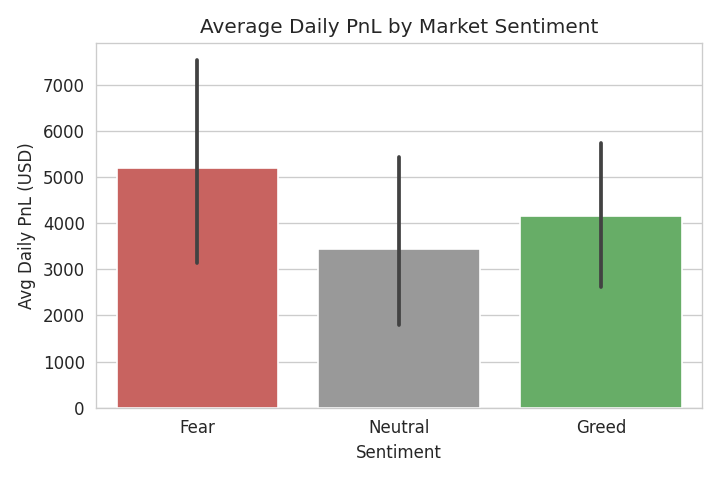

02_trades_per_day_by_sentiment.png


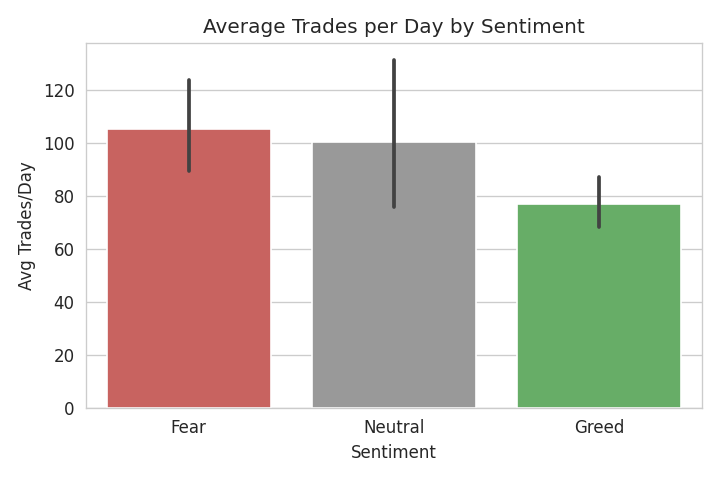

03_long_short_ratio_by_sentiment.png


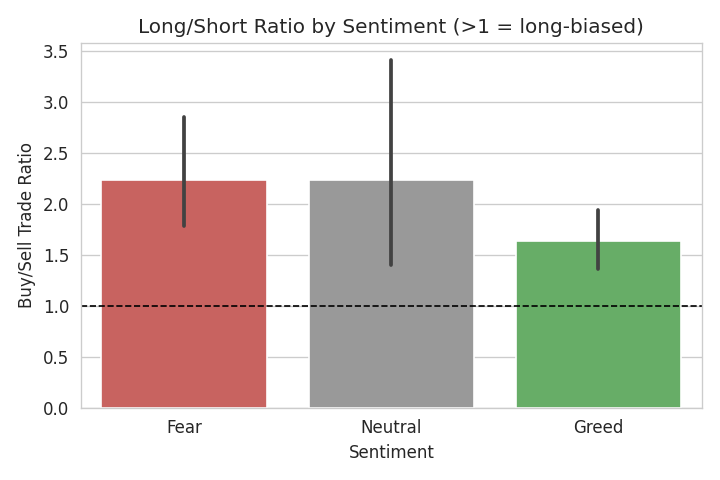

04_avg_trade_size_by_sentiment.png


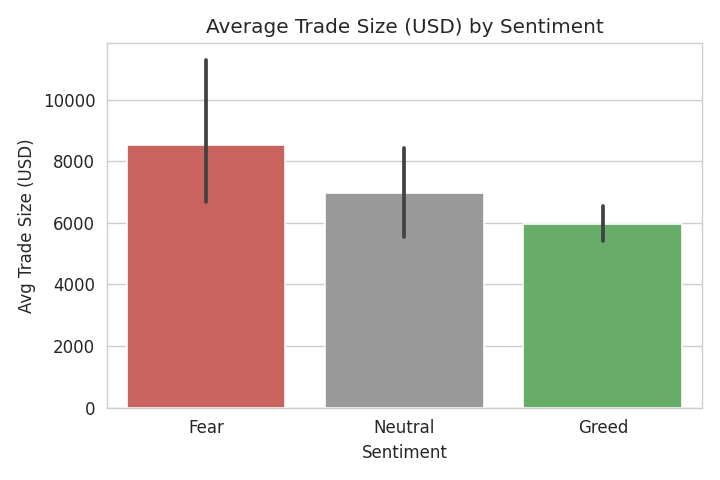

05_pnl_by_sizetier_sentiment.png


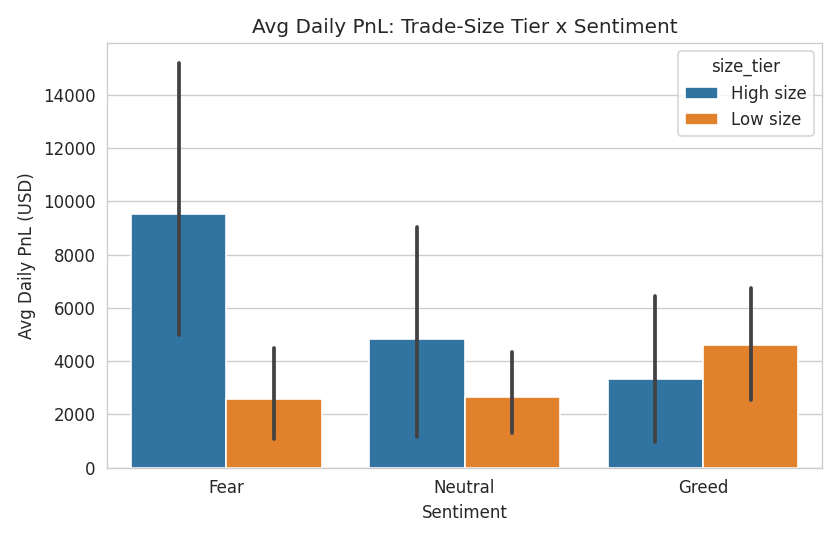

06_pnl_by_freqtier_sentiment.png


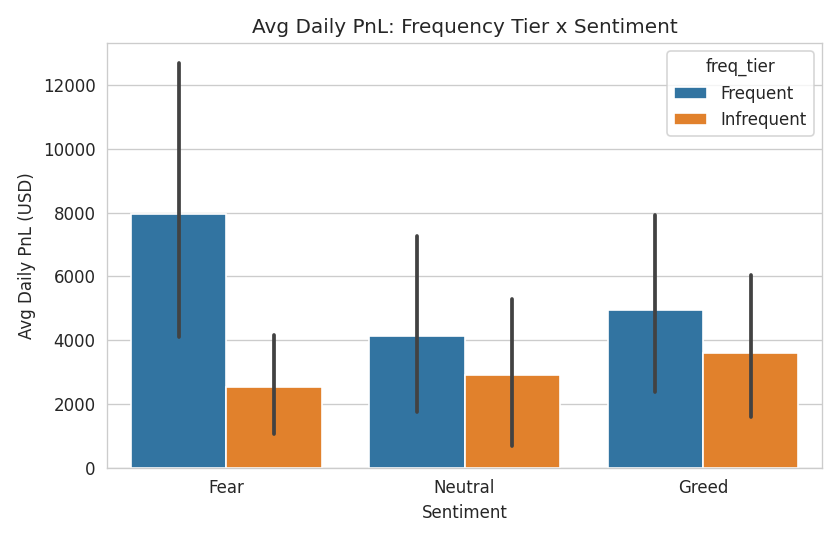

07_pnl_by_consistencytier_sentiment.png


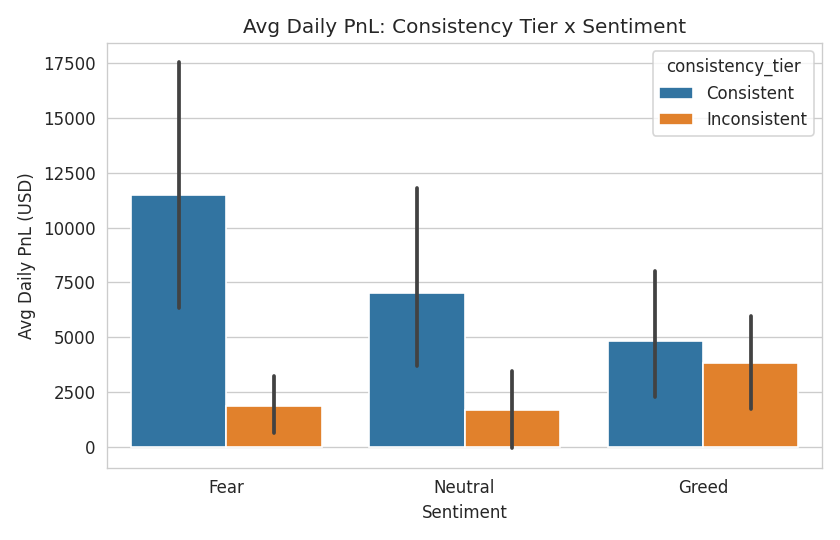

08_pnl_distribution_by_sentiment.png


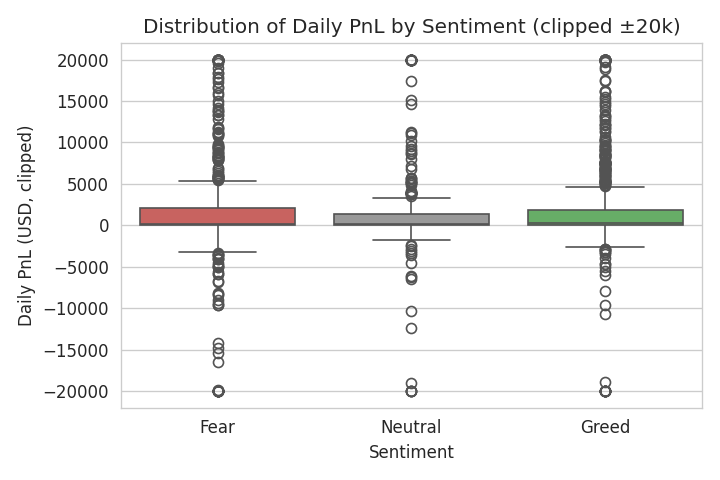

09_pnl_vs_sentiment_timeseries.png


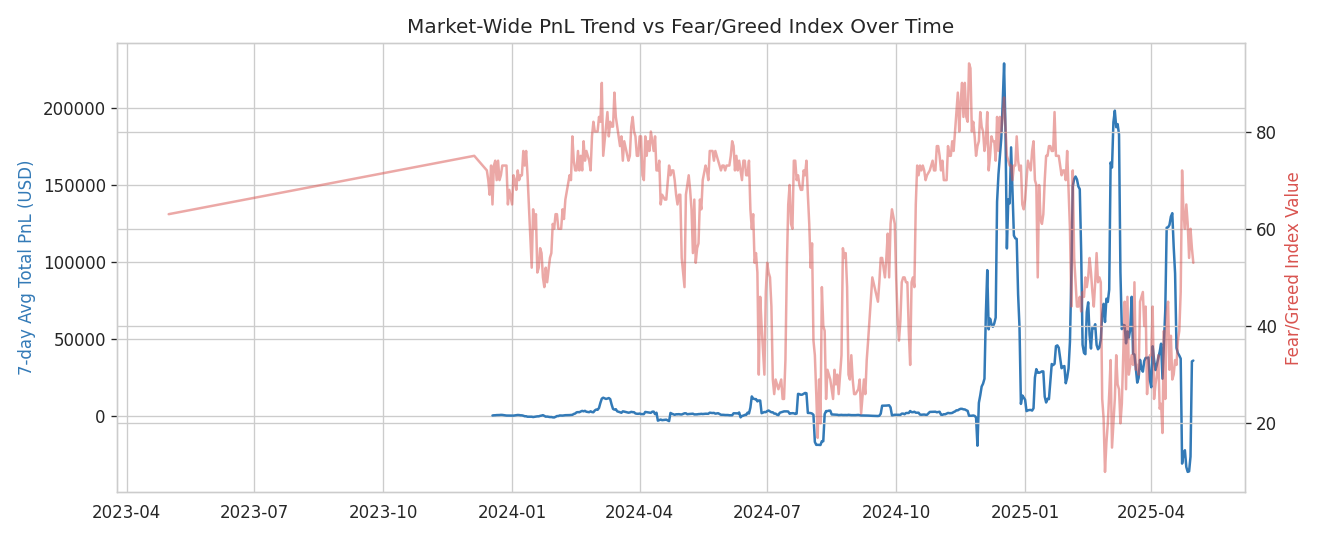

In [4]:
from IPython.display import Image, display
import os
for f in sorted(os.listdir('outputs/charts')):
    print(f)
    display(Image(filename=f'outputs/charts/{f}'))


## Bonus — Predictive Model & Trader Archetypes

In [5]:
"""
Bonus:
- Predict next-day account profitability bucket (profit vs loss) using
  sentiment + prior-day behavior features
- Cluster traders into behavioral archetypes
"""
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

daily = pd.read_csv('outputs/tables/daily_account_metrics.csv')
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.dropna(subset=['sentiment']).sort_values(['Account', 'date'])

def bucket(s):
    if 'Fear' in s: return 'Fear'
    if 'Greed' in s: return 'Greed'
    return 'Neutral'
daily['sentiment_group'] = daily['sentiment'].apply(bucket)

# ---------- Predictive model ----------
# Features from day T, label = whether account is profitable on day T+1
daily['next_day_pnl'] = daily.groupby('Account')['total_pnl'].shift(-1)
daily['next_day_profitable'] = (daily['next_day_pnl'] > 0).astype(int)

feat_cols = ['trades', 'total_pnl', 'win_rate', 'avg_trade_size_usd',
             'total_volume_usd', 'long_short_ratio', 'sentiment_value']
model_df = daily.dropna(subset=feat_cols + ['next_day_profitable']).copy()
model_df['long_short_ratio'] = model_df['long_short_ratio'].fillna(1.0)

sent_dummies = pd.get_dummies(model_df['sentiment_group'], prefix='sent')
X = pd.concat([model_df[feat_cols], sent_dummies], axis=1)
y = model_df['next_day_profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

report_lines = ["## Bonus — Predictive Model: Next-Day Profitability\n"]
report_lines.append(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
report_lines.append(f"Baseline (majority class) accuracy: {max(y.mean(), 1-y.mean()):.3f}")
report_lines.append(f"Test ROC-AUC: {roc_auc_score(y_test, proba):.3f}\n")
report_lines.append("```\n" + classification_report(y_test, pred) + "\n```")

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
report_lines.append("\n**Feature importances:**\n" + importances.round(3).to_markdown())

# ---------- Clustering ----------
acct = pd.read_csv('outputs/tables/account_segments.csv')
cluster_feats = ['total_trades', 'avg_trade_size_usd', 'avg_daily_pnl', 'pnl_std', 'avg_win_rate', 'trades_per_active_day']
acct_c = acct.dropna(subset=cluster_feats).copy()
scaler = StandardScaler()
Xc = scaler.fit_transform(acct_c[cluster_feats])

km = KMeans(n_clusters=3, n_init=10, random_state=42)
acct_c['archetype'] = km.fit_predict(Xc)

archetype_profile = acct_c.groupby('archetype')[cluster_feats + ['total_pnl']].mean().round(2)
report_lines.append("\n## Bonus — Trader Archetype Clustering (k=3)\n")
report_lines.append(archetype_profile.to_markdown())
report_lines.append(f"\nCluster sizes: {acct_c['archetype'].value_counts().to_dict()}")

acct_c.to_csv('outputs/tables/account_archetypes.csv', index=False)

with open('outputs/tables/bonus_report.md', 'w') as f:
    f.write('\n'.join(report_lines))

print('\n'.join(report_lines))


## Bonus — Predictive Model: Next-Day Profitability

Train size: 1187, Test size: 396
Baseline (majority class) accuracy: 0.698
Test ROC-AUC: 0.647

```
              precision    recall  f1-score   support

           0       0.43      0.57      0.49       120
           1       0.78      0.66      0.72       276

    accuracy                           0.64       396
   macro avg       0.60      0.62      0.60       396
weighted avg       0.67      0.64      0.65       396

```

**Feature importances:**
|                    |     0 |
|:-------------------|------:|
| trades             | 0.18  |
| avg_trade_size_usd | 0.166 |
| total_pnl          | 0.154 |
| total_volume_usd   | 0.126 |
| sentiment_value    | 0.126 |
| long_short_ratio   | 0.117 |
| win_rate           | 0.097 |
| sent_Fear          | 0.017 |
| sent_Greed         | 0.01  |
| sent_Neutral       | 0.008 |

## Bonus — Trader Archetype Clustering (k=3)

|   archetype |   total_trades |   avg_trade_size_usd |   avg_daily_pnl

## Part C — Actionable Strategy Recommendations

See `WRITEUP.md` / `README.md` for the full methodology, insights, and strategy rules of thumb.

**Quick summary of strategy ideas:**

1. **Scale position size with conviction only on Fear days, not Greed days** — the data shows high-size, high-frequency, and "consistent" traders realize meaningfully larger average daily PnL specifically on Fear days, while performance across tiers converges (or even mildly favors smaller/less frequent traders) on Greed days. Rule of thumb: increase size/leverage on Fear days only if you belong to the "consistent" or "frequent" segment; otherwise keep size flat or reduced.
2. **Trim long bias and trade frequency on Greed days for less consistent traders** — long/short ratio and trade counts rise in Fear vs Greed, but inconsistent traders' edge does not scale with activity. Rule of thumb: inconsistent traders should reduce trade frequency and long-side bias during Greed regimes rather than chasing momentum, since their historical PnL does not compound with extra activity in that regime.
